In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.svm import SVR, SVC
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import seaborn as sns

# **PROCESS MODELING ASSIGNMENT – REACTIVE-ION PLASMA ETCHING PROCESS:**




In [14]:
np.random.seed(42)

# Read data
column_names = ['Run', 'Pressure', 'Power', 'Electrode', 'CCl4', 'He',
                'O2', 'Etch Rate', 'Uniformity', 'Oxide', 'Photoresist']

data = pd.read_excel('/content/Reactive Ion.xlsx', header=5, names=column_names, usecols=range(1, 11))

# Separate features and targets
X = data.iloc[:, :6]
y = data.iloc[:, 6:]

# Split data into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Standardize features
scaler_X = StandardScaler()
X_train_scaled = scaler_X.fit_transform(X_train)
X_test_scaled = scaler_X.transform(X_test)

# Standardize target variables
scaler_y = StandardScaler()
y_train_scaled = scaler_y.fit_transform(y_train)
y_test_scaled = scaler_y.transform(y_test)

data.tail()
data.describe().transpose()

,count,mean,std,min,25%,50%,75%,max
Pressure,51.0,250.000000,45.458113,131.00,200.000,250.00,300.00,369.00
Power,51.0,350.000000,45.458113,231.00,300.000,350.00,400.00,469.00
Electrode,51.0,1.507843,0.285547,0.80,1.200,1.50,1.80,2.20
CCl4,51.0,125.941176,22.762611,64.00,100.000,125.00,150.00,184.00
He,51.0,124.019608,61.636187,0.00,50.000,125.00,200.00,200.00
O2,51.0,15.000000,4.556314,3.00,10.000,15.00,20.00,27.00
Etch Rate,51.0,4224.549020,694.043812,2704.00,3703.500,4408.00,4714.50,5515.00
Uniformity,51.0,11.737255,10.797295,0.50,4.250,8.30,15.10,55.20
Oxide,51.0,7.018039,2.224303,2.65,5.805,6.41,7.77,15.15
Photoresist,51.0,2.237451,0.549253,1.32,1.970,2.10,2.34,4.17


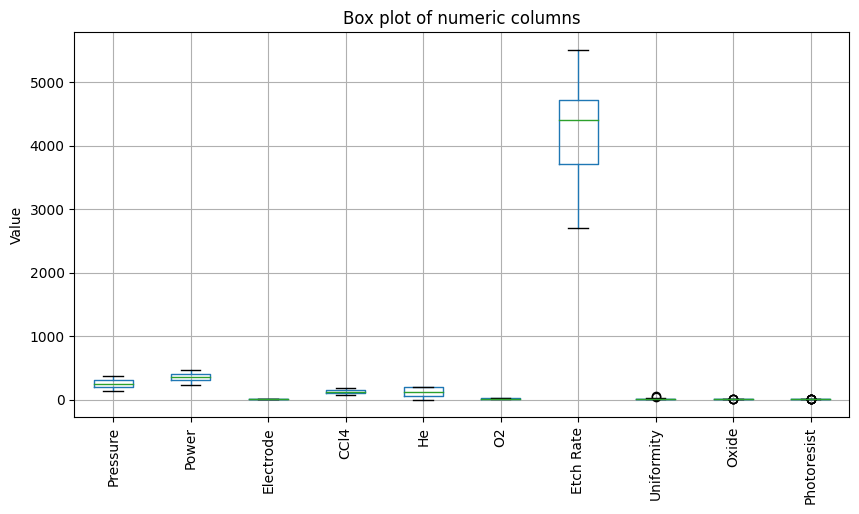

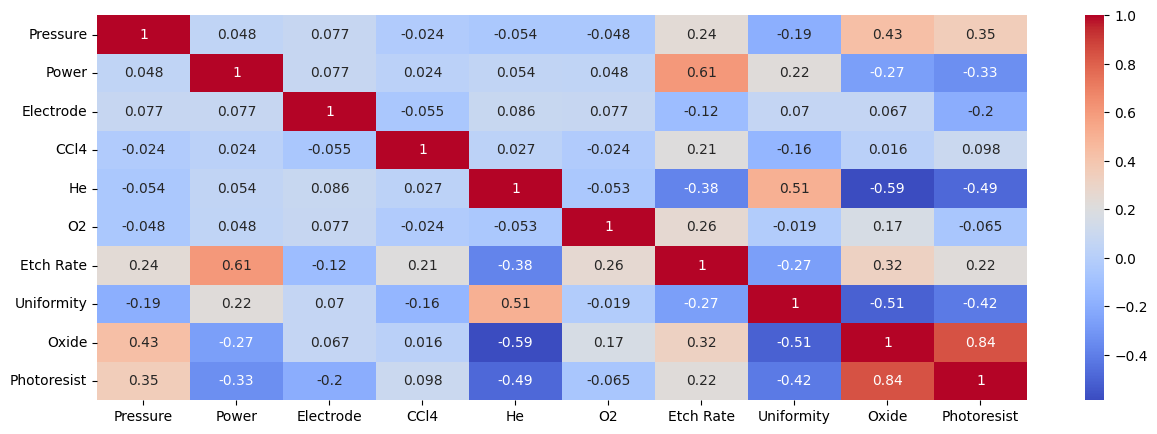

In [15]:
# Create a box plot of the numeric columns
fig, ax = plt.subplots(figsize=(10, 5))
data.boxplot(ax=ax)
plt.xticks(rotation=90)
plt.ylabel('Value')
plt.title('Box plot of numeric columns')
plt.show()

# Visualize correlation
fig, ax = plt.subplots(figsize=(15, 5))
sns.heatmap(data.corr(), annot=True, cmap='coolwarm')
plt.show()

In [22]:
# Reshape y_train_scaled
y_train_scaled_flat = y_train_scaled.flatten()

# Train separate models for each target variable
models = []
kernels = ['sigmoid', 'sigmoid', 'linear', 'sigmoid']

for i, kernel in enumerate(kernels):
    model = SVR(kernel=kernel, C=1.0, epsilon=0.1)
    model.fit(X_train_scaled, y_train_scaled[:, i])
    models.append(model)

# Predict on the test set for each target variable
y_pred_scaled = np.array([model.predict(X_test_scaled) for model in models]).T

# Scale predictions back to original scale
y_pred = scaler_y.inverse_transform(y_pred_scaled)

# Calculate R^2 and MAE for each target variable
r2_scores = []
mae_scores = []
mse_scores = []  # Add a list to store MSE scores
targets = ['Etch Rate', 'Uniformity', 'Oxide', 'Photoresist']
for i, target in enumerate(targets):
    r2 = r2_score(y_test[target], y_pred[:, i])
    r2_scores.append(r2)
    mae = mean_absolute_error(y_test[target], y_pred[:, i])
    mae_scores.append(mae)
    mse = mean_squared_error(y_test[target], y_pred[:, i])  # Calculate MSE
    mse_scores.append(mse)  # Append MSE to the list
    print(f'R^2 score for {target}: {r2:.3f}')
    print(f'MAE for {target}: {mae:.3f}')
    print(f'MSE for {target}: {mse:.3f}')

R^2 score for Etch Rate: 0.609
MAE for Etch Rate: 297.734
MSE for Etch Rate: 235365.710
R^2 score for Uniformity: 0.164
MAE for Uniformity: 6.457
MSE for Uniformity: 57.373
R^2 score for Oxide: 0.532
MAE for Oxide: 1.438
MSE for Oxide: 3.695
R^2 score for Photoresist: 0.588
MAE for Photoresist: 0.255
MSE for Photoresist: 0.125


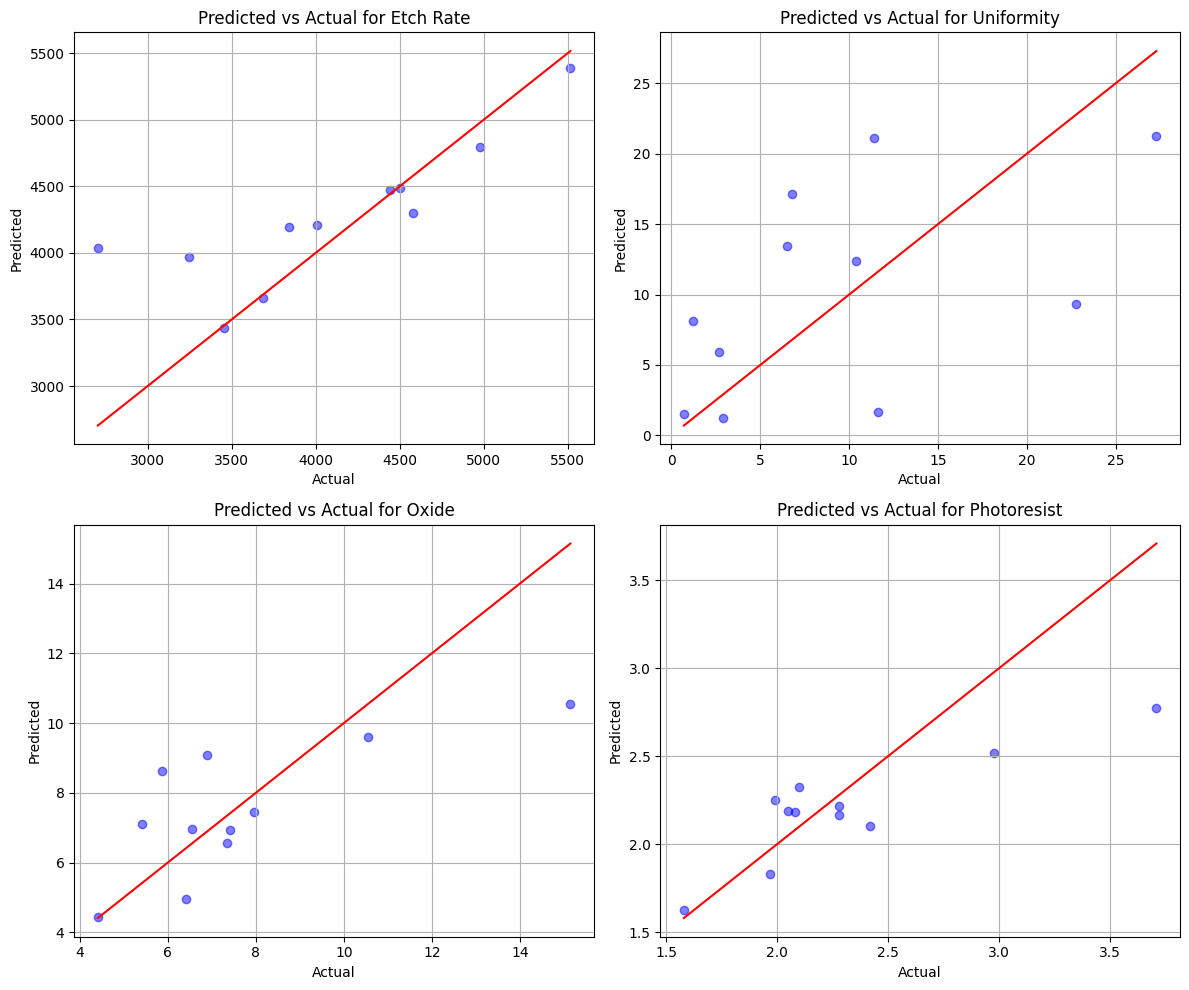

In [5]:
# Plotting
plt.figure(figsize=(12, 10))
for i, target in enumerate(targets):
    plt.subplot(2, 2, i+1)
    plt.scatter(y_test[target], y_pred[:, i], color='blue', alpha=0.5)
    plt.plot([min(y_test[target]), max(y_test[target])], [min(y_test[target]), max(y_test[target])], color='red')
    plt.title(f'Predicted vs Actual for {target}')
    plt.xlabel('Actual')
    plt.ylabel('Predicted')
    plt.grid(True)
plt.tight_layout()
plt.show()

# **NON-SEPARABLE CLASSIFICATION ASSIGNMENT – MULTI-FONT CHARACTER RECOGNITION:**

In [6]:
np.random.seed(42)

# Load training data
df_train = pd.read_excel('/content/Multi-font Character Recognition Training.xlsx')
df_train.columns = df_train.columns.astype(str)

# Load testing data
df_test = pd.read_excel('/content/Multi-font Testing Data Set.xlsx')
df_test.columns = df_test.columns.astype(str)

# Separate features and labels for training data
X_train = df_train.iloc[:, :14]
y_train = df_train.iloc[:, 14:]

# Separate features and labels for testing data
X_test = df_test.iloc[:, :14]
y_test = df_test.iloc[:, 14:]

# Standardize features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)

# Match column names for testing data
X_test.columns = X_train.columns
X_test_scaled = scaler.transform(X_test)

In [7]:
# Define and train the SVM model
svm_model = SVC(kernel='rbf', C=1.0, gamma='scale', random_state=42)
svm_model.fit(X_train_scaled, np.argmax(y_train.values, axis=1))

# Predictions on the testing data
predictions = svm_model.predict(X_test_scaled)

# Mean Squared Error
mse = mean_squared_error(np.argmax(y_test.values, axis=1), predictions)
print("Mean Squared Error = ", mse)

# Calculate Accuracy
accuracy = accuracy_score(np.argmax(y_test.values, axis=1), predictions)
print(f"Test Accuracy: {accuracy}")

Mean Squared Error =  21.987179487179485
Test Accuracy: 0.8205128205128205


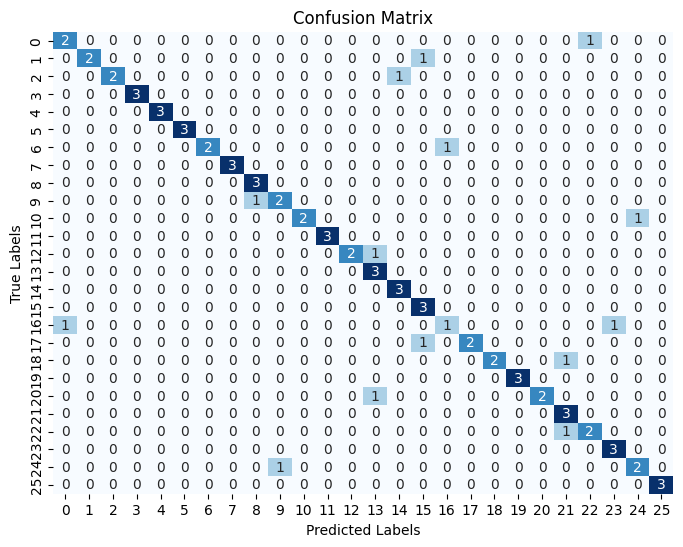

In [8]:
# Create confusion matrix
cm = confusion_matrix(np.argmax(y_test.values, axis=1), predictions)

# Plot confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix')
plt.show()

# ***NON-SEPARABLE CLASSIFICATION – PATTERN RECOGNITION IN PROCESS CONTROL CHARTS:***

In [9]:
np.random.seed(42)

# Load data
training_data = np.loadtxt('/content/SPC-Training.txt')
testing_data = np.loadtxt('/content/SPC-Testing.txt')

# Separate features and labels
X_train, y_train = training_data[:, :10], training_data[:, 10:]
X_test, y_test = testing_data[:, :10], testing_data[:, 10:]

# Scale the data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [10]:
# Define and train the SVM model
svm_model = SVC(kernel='rbf', C=1.0, gamma='scale', random_state=42)
svm_model.fit(X_train_scaled, np.argmax(y_train, axis=1))

# Predictions
y_pred = svm_model.predict(X_test_scaled)

mse = mean_squared_error(np.argmax(y_test, axis=1), y_pred)
print('Mean Squared Error:', mse)

test_acc = accuracy_score(np.argmax(y_test, axis=1), y_pred)
print('Test accuracy:', test_acc)

Mean Squared Error: 0.836
Test accuracy: 0.884


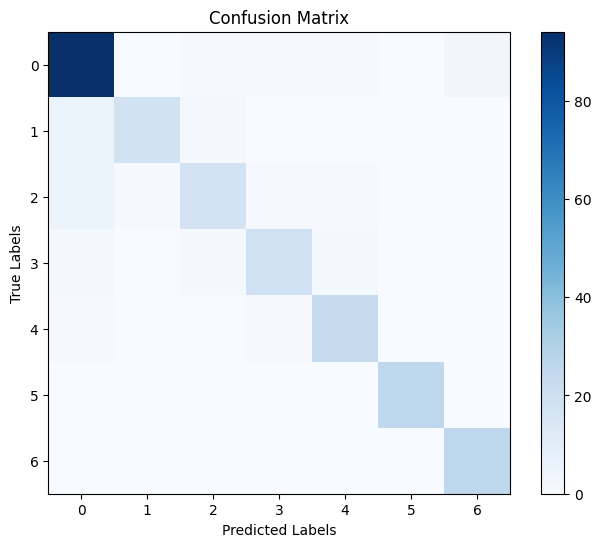

              precision    recall  f1-score   support

           0       0.88      0.94      0.91       100
           1       0.95      0.72      0.82        25
           2       0.77      0.68      0.72        25
           3       0.86      0.76      0.81        25
           4       0.85      0.92      0.88        25
           5       1.00      1.00      1.00        25
           6       0.89      1.00      0.94        25

    accuracy                           0.88       250
   macro avg       0.89      0.86      0.87       250
weighted avg       0.88      0.88      0.88       250



In [11]:
# Plot confusion matrix
conf_mat = confusion_matrix(np.argmax(y_test, axis=1), y_pred)
plt.figure(figsize=(8, 6))
plt.imshow(conf_mat, cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
plt.colorbar()
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.show()

# Print classification report
print(classification_report(np.argmax(y_test, axis=1), y_pred))